# Decoding the belief state from an RNN

In [1]:
import os
import numpy as np; np.set_printoptions(linewidth=150)
import torch; torch.set_printoptions(linewidth=150)
from torch import nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pickle

In [2]:
from environment import CliffWalk, InfiniteWalk
from episodes import Episode, collect_episodes, EpisodeCollection
from belief_decoders import NonLinBeliefDecoder, LinBeliefDecoder, decode_training, decode_visualisation, estimate_entropy
from belief_rnn import BeliefRNN, RewardReadout, ValueReadout, NextLatentPredictor, ObsReadout
from train import train, plot_validate

### Actual stuff

In [6]:
N, M = 3, 8
cliff = CliffWalk(n=N, m=M, self_transition_prob=0.1, gamma=1.0)
policy = cliff.get_optimal_policy(epsilon=1.0)
print(policy)

# Collect episodes from the environment using the target policy
episode_list = collect_episodes(cliff, policy, num_episodes=10000)

episodes = EpisodeCollection(episode_list)
print(np.mean(episodes.ep_lengths))

print("Empirical State Value function:")
value_empirical = episodes.get_monte_carlo_state_values(gamma=cliff.gamma)
print(np.flip(value_empirical.reshape((cliff.n, cliff.m)), axis=0))

[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]
10.2622
Empirical State Value function:
[[ -9.65  -9.56  -9.16  -8.6   -7.88  -7.03  -5.3   -3.44]
 [ -9.78  -9.7   -9.55  -9.39  -9.01  -7.74  -4.72   0.74]
 [ -9.89 -10.   -10.   -10.   -10.   -10.   -10.    10.  ]]


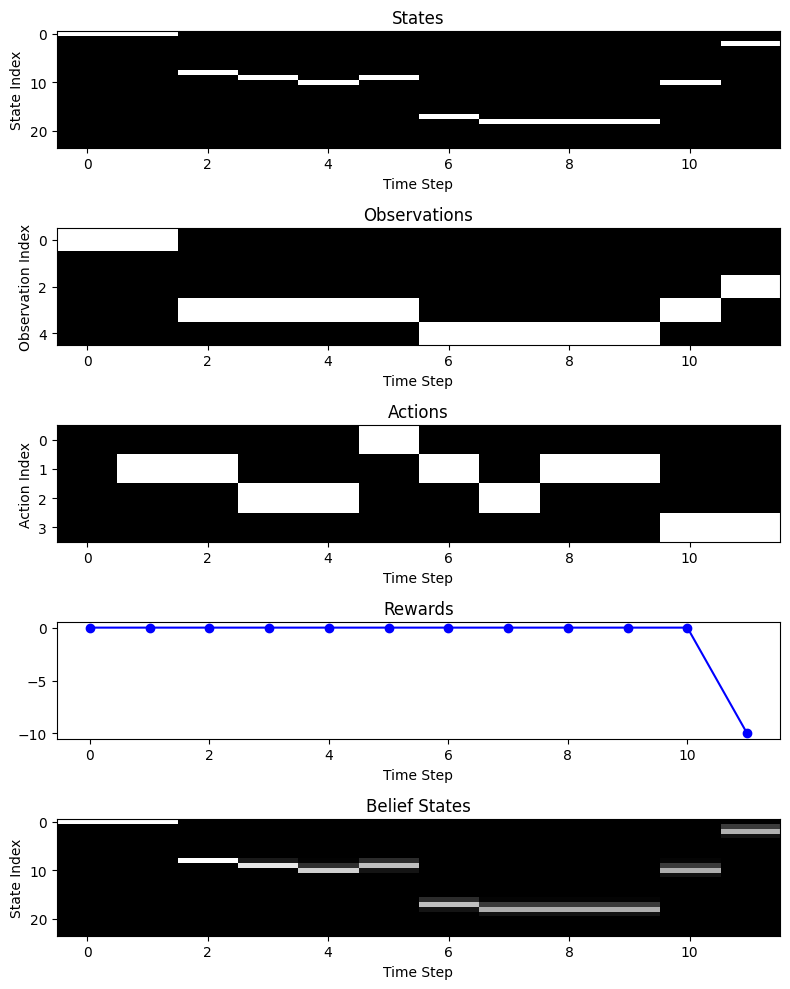

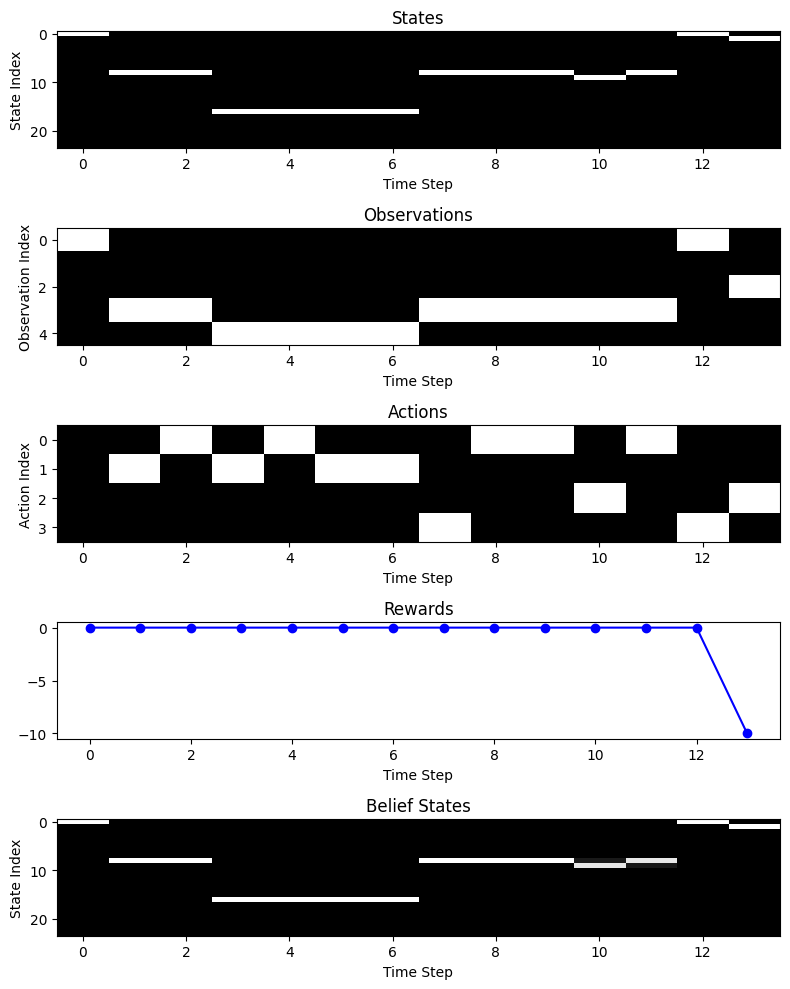

In [7]:
test_episodes = []

# Get an out of sample test episode to validate the model
test_ep_len = 0
while test_ep_len < 10:
    test_episode = collect_episodes(cliff, policy, num_episodes=1)[0]
    test_ep_len = len(test_episode.history)
test_episode.render()
test_episodes.append(test_episode)

test_ep_len = 0
i = 0
while test_ep_len < 10:
    test_episode = episodes.episodes[i]
    test_ep_len = len(test_episode.history)
    i += 1
test_episode.render()
test_episodes.append(test_episode)

Linear Values:
[ -9.89  -9.89  -9.78  -9.71  -9.58  -9.7   -9.54  -9.22  -9.22  -9.22  -9.58 -10.  ]
History Values:
[-1.33, -1.36, -0.56, -0.76, -0.37, -0.67, 3.56, 3.33, 2.0, nan, nan, nan]
Predicted Values:
[ 0.01  0.   -0.01  0.02  0.03  0.04  0.03  0.05  0.03  0.02  0.02  0.02]


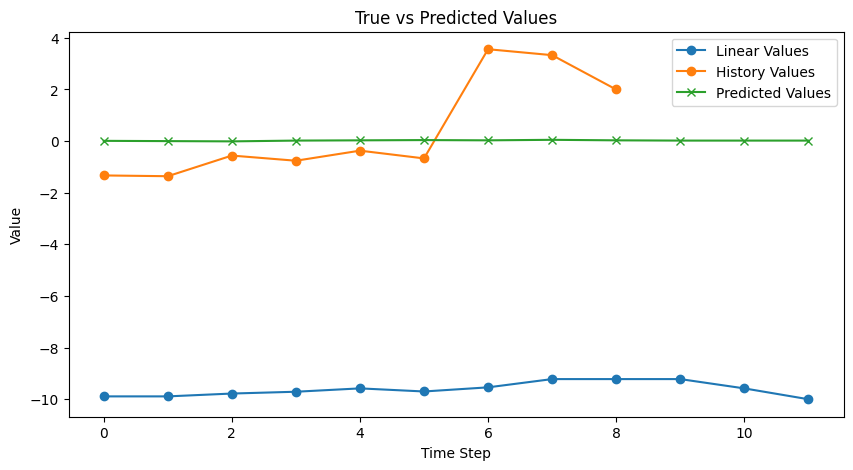

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.   -0.01  0.02  0.03  0.04  0.07  0.03  0.01 -0.01 -0.01  0.04  0.03]


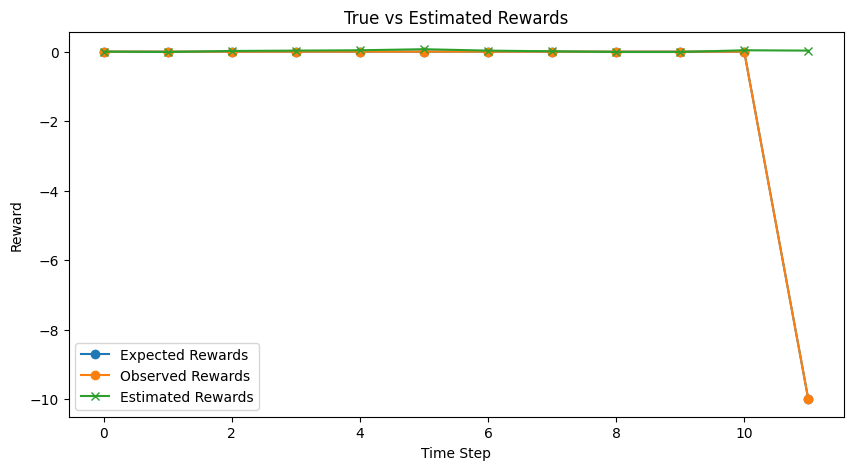

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -8.85]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[0.08 0.08 0.08 0.07 0.02 0.07 0.06 0.06 0.06 0.03 0.03]


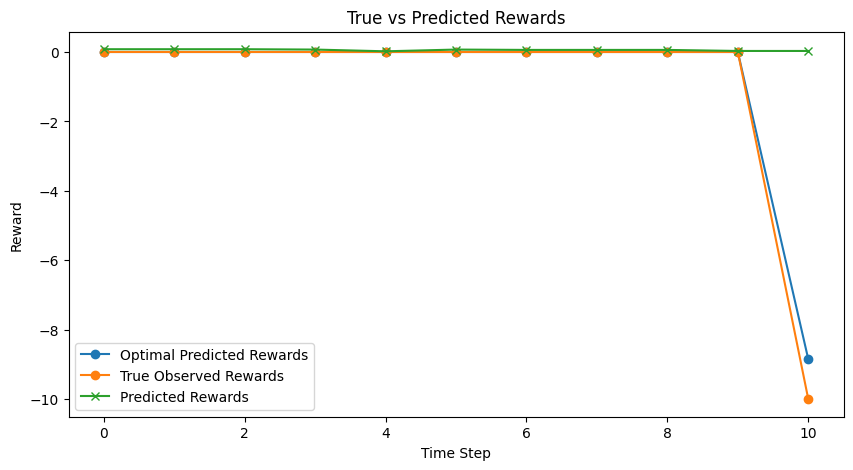

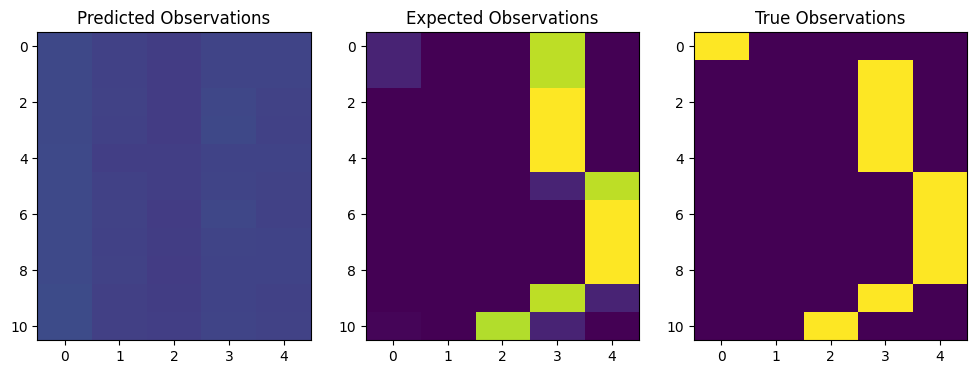

Linear Values:
[ -9.89  -9.78  -9.78  -9.65  -9.65  -9.65  -9.65  -9.78  -9.78  -9.78  -9.71  -9.77  -9.89 -10.  ]
History Values:
[-1.33, -0.49, -0.56, 2.76, 2.95, 8.18, nan, nan, nan, nan, nan, nan, nan, nan]
Predicted Values:
[0.01 0.   0.03 0.02 0.05 0.03 0.03 0.02 0.04 0.05 0.04 0.05 0.04 0.05]


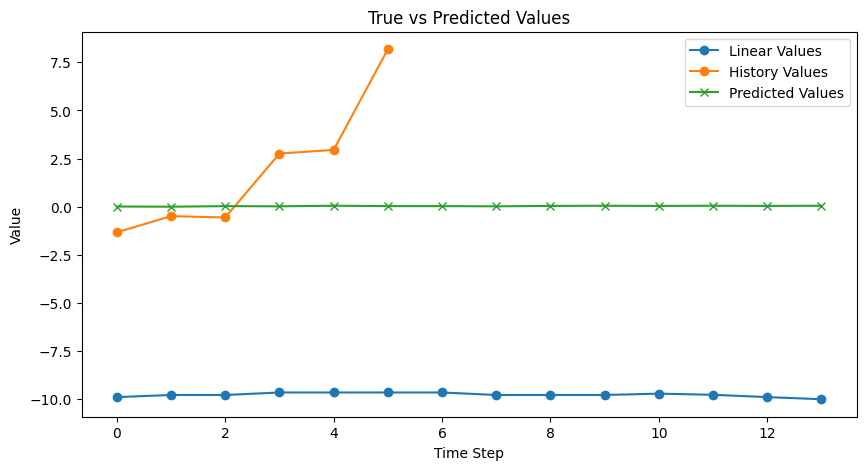

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.    0.02  0.06  0.02  0.02 -0.   -0.01  0.04  0.05  0.07  0.05  0.07  0.07  0.02]


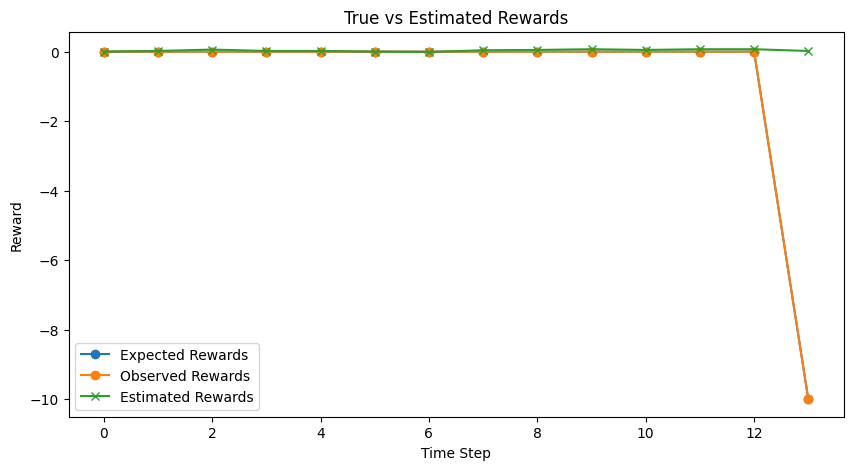

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -0.81 -9.  ]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[0.08 0.04 0.07 0.03 0.07 0.06 0.03 0.03 0.03 0.06 0.02 0.03 0.06]


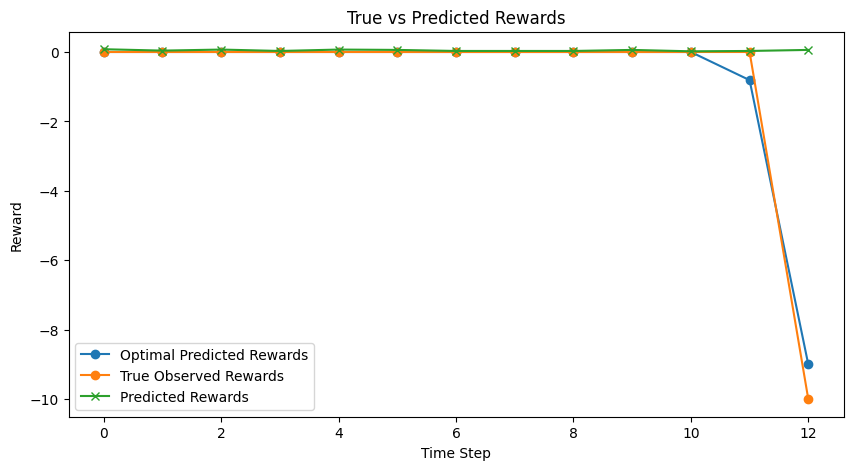

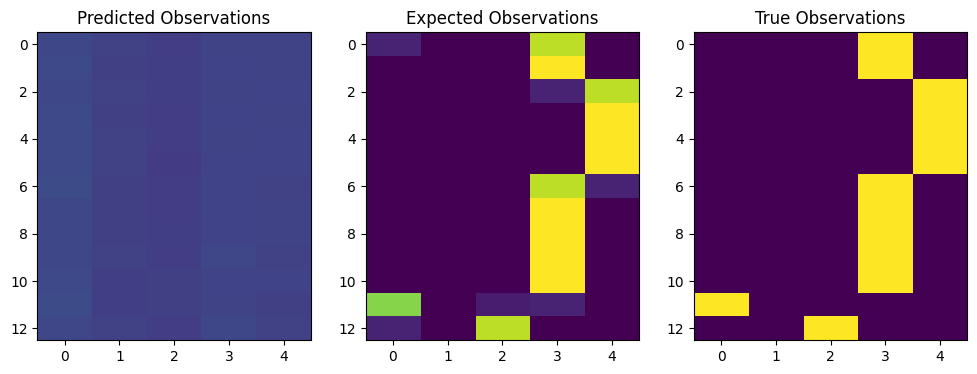

In [8]:
RNN_HIDDEN = 64

belief_model = BeliefRNN(input_dim=episodes.H, latent_dim=RNN_HIDDEN)
value_model = ValueReadout(RNN_HIDDEN)
reward_model = RewardReadout(RNN_HIDDEN)
pred_model = NextLatentPredictor(RNN_HIDDEN)
obs_model = ObsReadout(RNN_HIDDEN, 5)

models = belief_model, value_model, reward_model, pred_model, obs_model

plot_validate(models, test_episodes, cliff, history_vtable, value_empirical)

In [9]:
def plot_train_losses(losses):
    loss_td_history, loss_mc_history, loss_obs_history, loss_rew_history, value_err_history, loss_rewpred_history = losses
    plt.plot(loss_td_history, label='TD Loss')
    plt.plot(loss_mc_history, label='MC Loss')
    plt.plot(loss_obs_history, label='Observation Loss')
    plt.plot(loss_rew_history, label='Reward Loss')
    plt.plot(loss_rewpred_history, label='Reward Pred Loss')
    plt.plot(value_err_history, label='Value Error')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Losses')
    plt.legend()
    plt.show()


Epoch 1, TD Loss: 10.03, MC Loss: 0.0, Pred O Loss: 15.86, Est R Loss: 9.96, Pred R Loss: 11.19 Total: 47.04, Value Loss: 9.65     
Epoch 50, TD Loss: 6.91, MC Loss: 0.0, Pred O Loss: 7.72, Est R Loss: 8.65, Pred R Loss: 8.22 Total: 31.5, Value Loss: 3.47         
Epoch 100, TD Loss: 1.09, MC Loss: 0.0, Pred O Loss: 3.32, Est R Loss: 8.13, Pred R Loss: 7.08 Total: 19.62, Value Loss: 1.64     
Epoch 150, TD Loss: 0.25, MC Loss: 0.0, Pred O Loss: 2.14, Est R Loss: 7.65, Pred R Loss: 6.63 Total: 16.67, Value Loss: 1.05     
Epoch 200, TD Loss: 0.16, MC Loss: 0.0, Pred O Loss: 1.89, Est R Loss: 6.6, Pred R Loss: 5.28 Total: 13.93, Value Loss: 0.98      
Epoch 250, TD Loss: 0.15, MC Loss: 0.0, Pred O Loss: 1.82, Est R Loss: 5.48, Pred R Loss: 3.61 Total: 11.06, Value Loss: 0.83     
Epoch 300, TD Loss: 0.18, MC Loss: 0.0, Pred O Loss: 1.73, Est R Loss: 4.08, Pred R Loss: 2.88 Total: 8.87, Value Loss: 1.23      
Epoch 350, TD Loss: 0.41, MC Loss: 0.0, Pred O Loss: 1.64, Est R Loss: 2.94, Pre

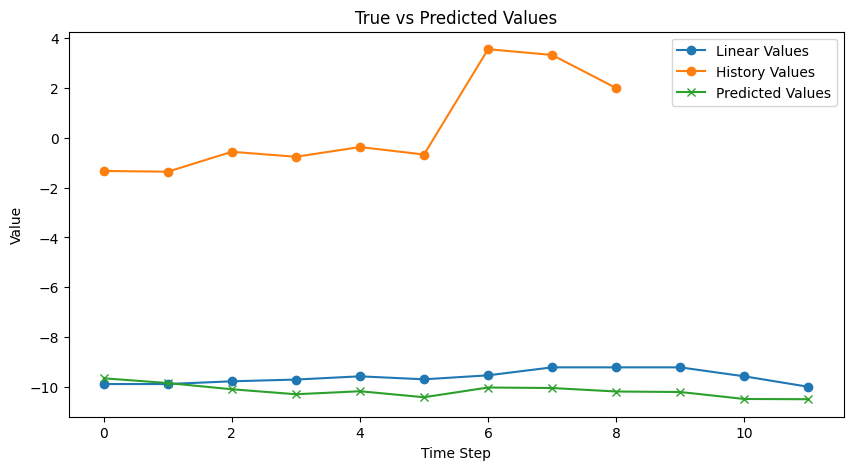

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[ 0.22 -0.36  0.27 -0.74 -1.39  0.07 -0.45 -1.03  0.16  0.48  0.57 -7.05]


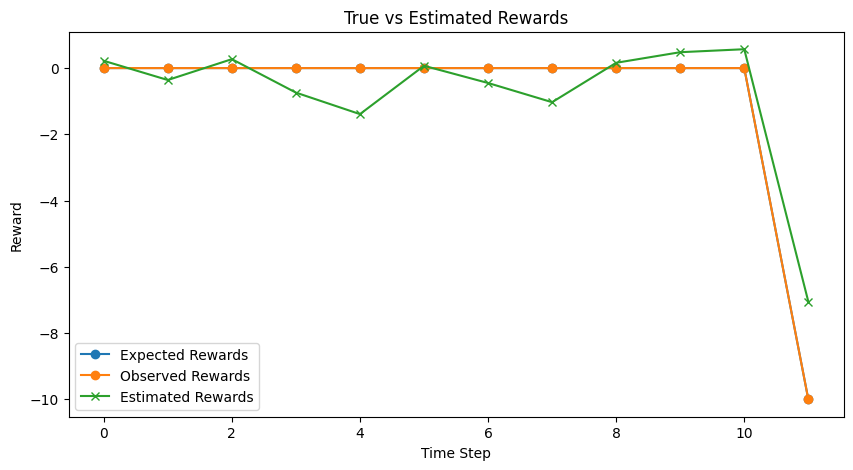

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -8.85]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.12 -0.11 -0.45 -0.21 -0.52 -0.09  0.01  0.04 -0.04  0.06 -5.36]


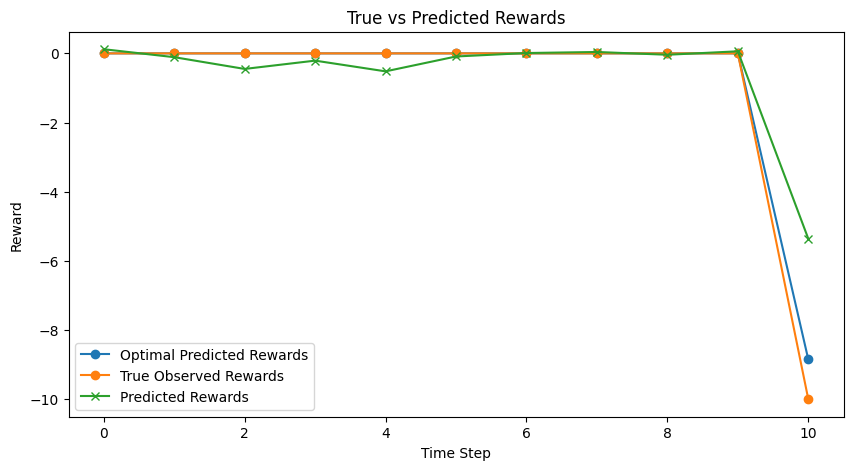

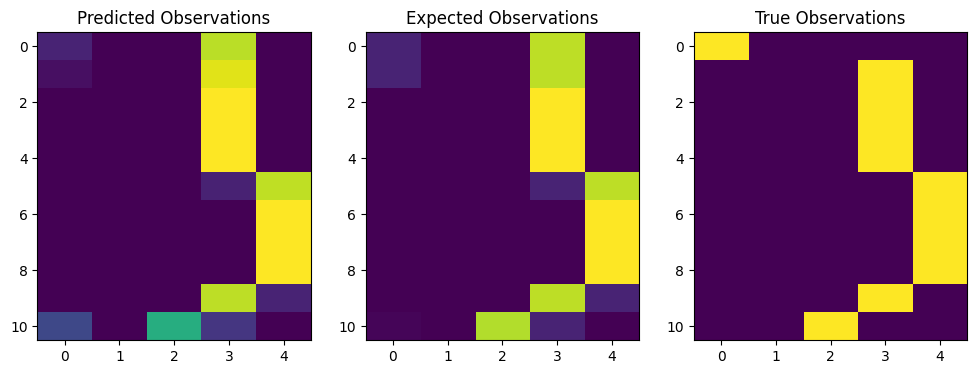

Linear Values:
[ -9.89  -9.78  -9.78  -9.65  -9.65  -9.65  -9.65  -9.78  -9.78  -9.78  -9.71  -9.77  -9.89 -10.  ]
History Values:
[-1.33, -0.49, -0.56, 2.76, 2.95, 8.18, nan, nan, nan, nan, nan, nan, nan, nan]
Predicted Values:
[ -9.66  -9.84 -10.23  -9.86  -9.98  -9.91 -10.01 -10.4  -10.31 -10.34 -10.21 -10.36 -10.19 -10.07]


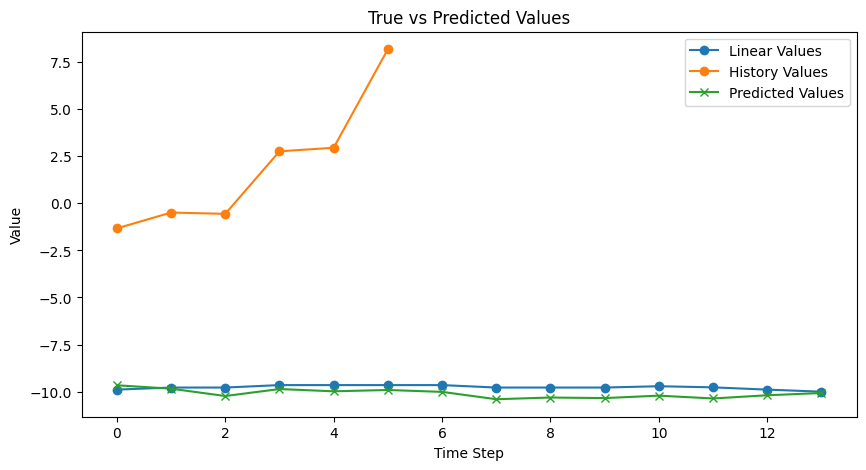

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[ 0.22 -0.01  0.73 -0.12  0.55  0.63  0.77  0.79  0.48  0.53 -1.15  0.2  -0.73 -8.72]


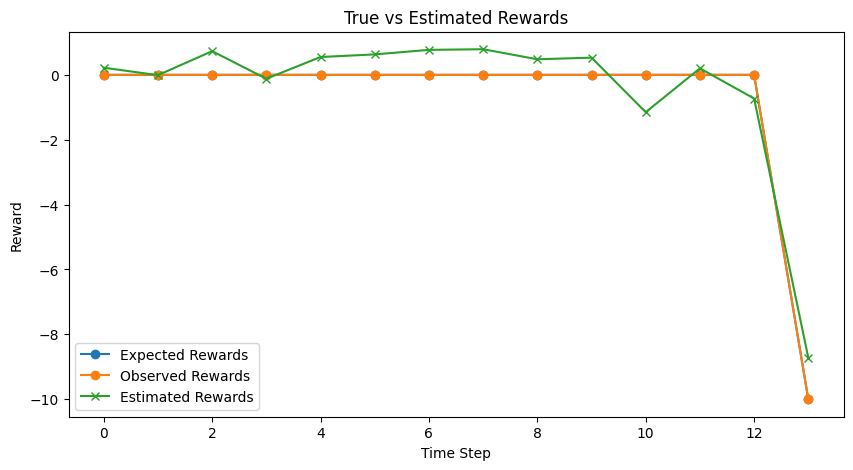

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -0.81 -9.  ]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.12  0.65  0.35 -0.2  -0.05 -0.17  0.69 -0.09  0.27  0.08 -0.4  -3.97 -9.31]


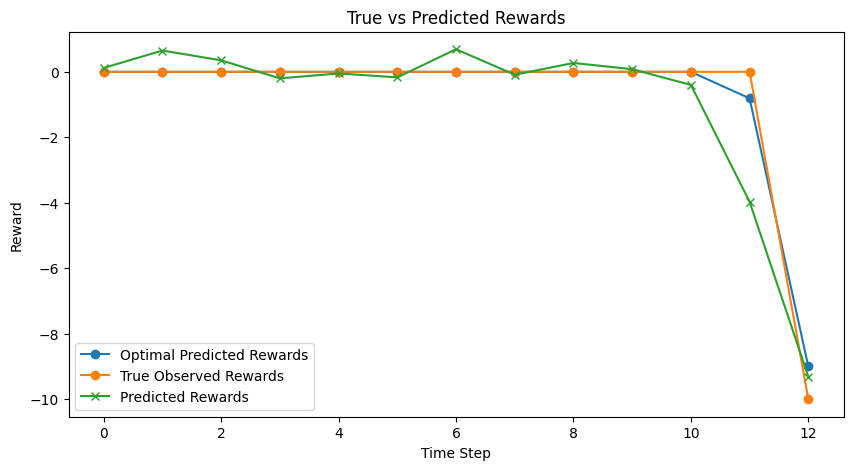

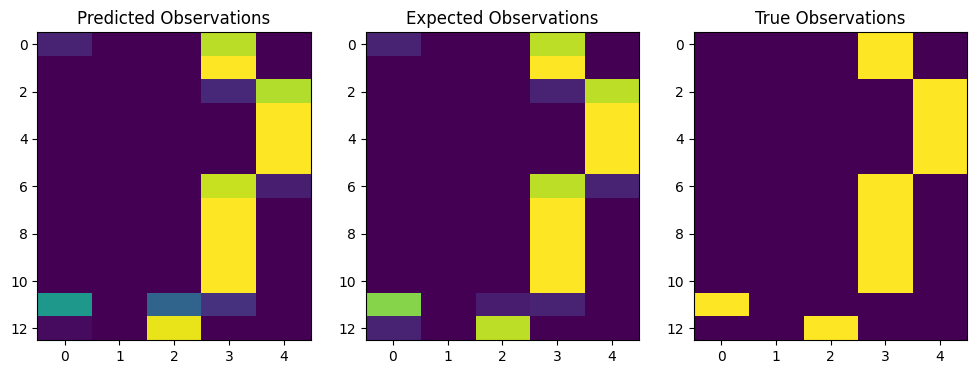

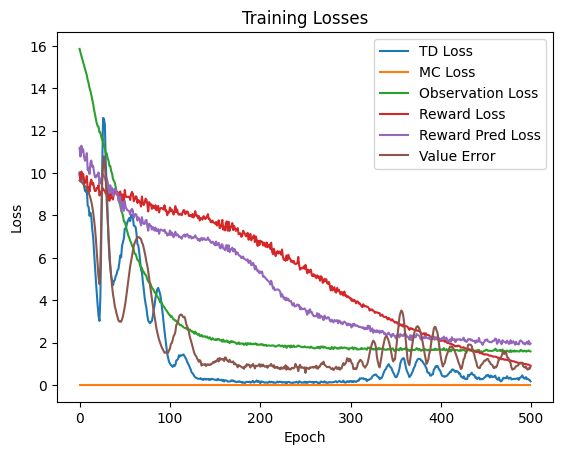

Epoch 1, TD Loss: 0.28, MC Loss: 0.0, Pred O Loss: 1.66, Est R Loss: 0.94, Pred R Loss: 2.01 Total: 4.89, Value Loss: 0.98     
Epoch 50, TD Loss: 0.59, MC Loss: 0.0, Pred O Loss: 1.57, Est R Loss: 0.42, Pred R Loss: 1.9 Total: 4.48, Value Loss: 1.11      
Epoch 100, TD Loss: 0.53, MC Loss: 0.0, Pred O Loss: 1.52, Est R Loss: 0.17, Pred R Loss: 1.78 Total: 4.0, Value Loss: 0.93     
Epoch 150, TD Loss: 0.42, MC Loss: 0.0, Pred O Loss: 1.5, Est R Loss: 0.08, Pred R Loss: 1.69 Total: 3.69, Value Loss: 0.71      
Epoch 200, TD Loss: 0.3, MC Loss: 0.0, Pred O Loss: 1.47, Est R Loss: 0.05, Pred R Loss: 1.59 Total: 3.41, Value Loss: 0.86      
Epoch 250, TD Loss: 0.71, MC Loss: 0.0, Pred O Loss: 1.51, Est R Loss: 0.04, Pred R Loss: 1.69 Total: 3.95, Value Loss: 0.93     
Epoch 300, TD Loss: 0.49, MC Loss: 0.0, Pred O Loss: 1.52, Est R Loss: 0.03, Pred R Loss: 1.67 Total: 3.71, Value Loss: 0.7      
Epoch 350, TD Loss: 0.39, MC Loss: 0.0, Pred O Loss: 1.53, Est R Loss: 0.05, Pred R Loss: 1.77

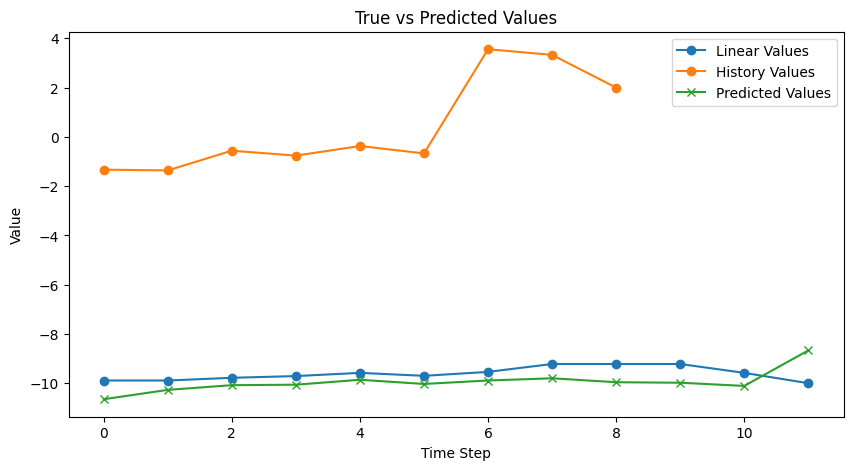

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.05  0.06  0.06  0.08  0.04  0.07 -0.    0.12  0.13  0.11  0.01 -9.86]


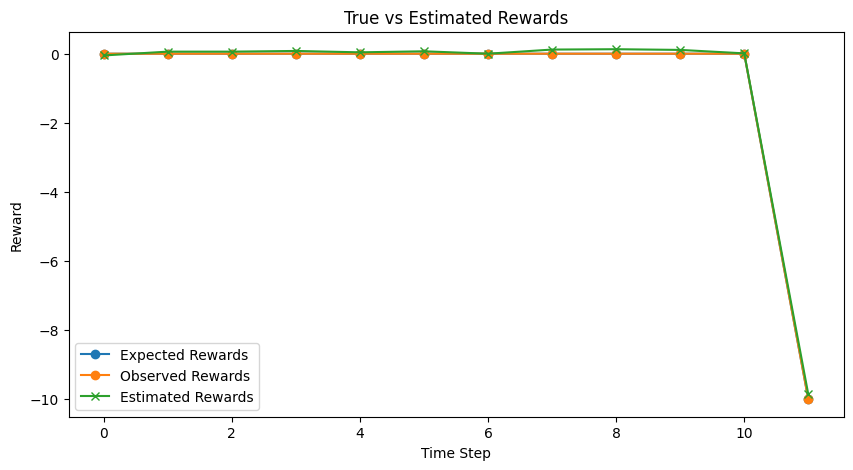

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -8.85]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.05 -0.2  -0.15 -0.08  0.06 -0.04  0.   -0.07 -0.09  0.05 -7.93]


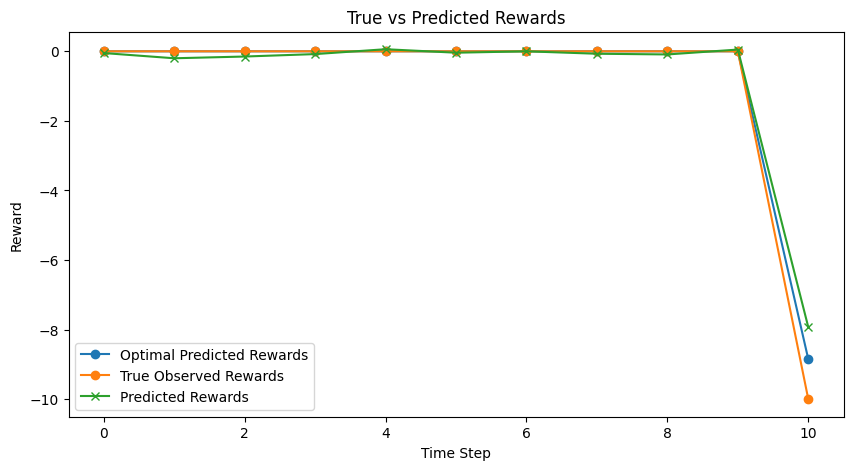

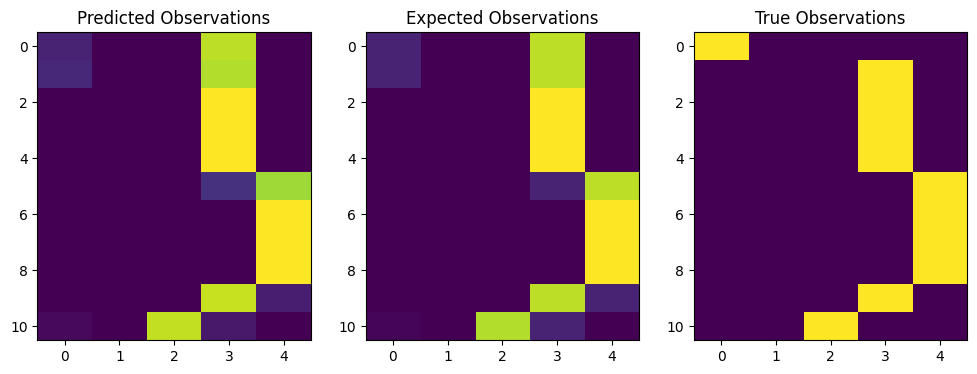

Linear Values:
[ -9.89  -9.78  -9.78  -9.65  -9.65  -9.65  -9.65  -9.78  -9.78  -9.78  -9.71  -9.77  -9.89 -10.  ]
History Values:
[-1.33, -0.49, -0.56, 2.76, 2.95, 8.18, nan, nan, nan, nan, nan, nan, nan, nan]
Predicted Values:
[-10.65 -10.   -10.1   -9.95 -10.08 -10.1  -10.07 -10.12 -10.13 -10.12 -10.09 -10.12 -10.25  -8.56]


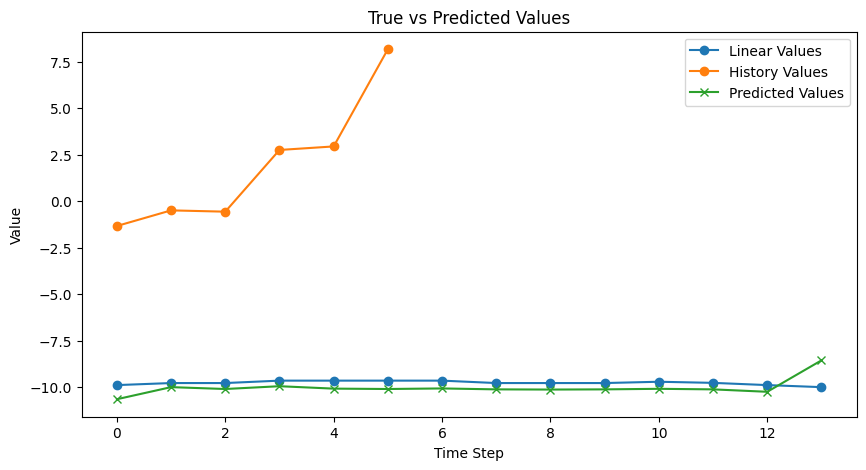

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[ -0.05  -0.04   0.11   0.04   0.02   0.07   0.04   0.11   0.06   0.1    0.04   0.04   0.06 -10.03]


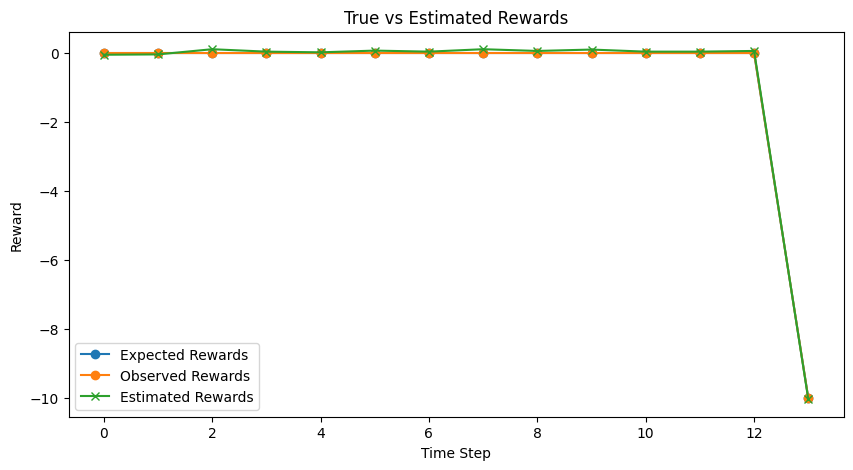

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -0.81 -9.  ]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.05  0.07  0.04 -0.17  0.03  0.02  0.06  0.24  0.18 -0.14 -0.33 -1.49 -9.25]


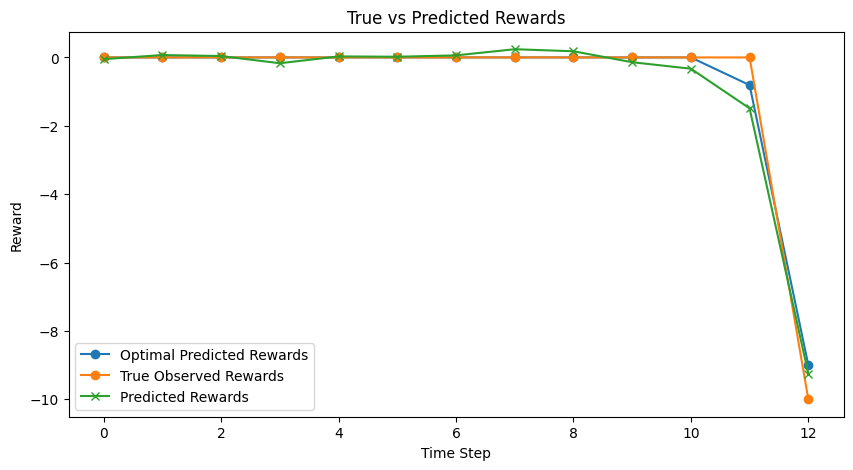

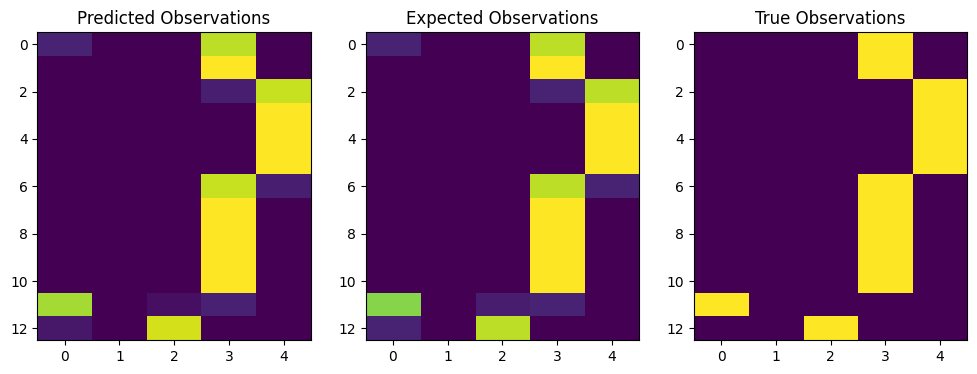

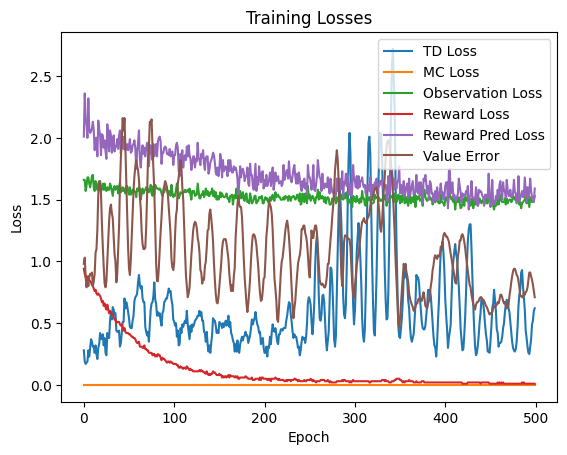

Epoch 1, TD Loss: 0.66, MC Loss: 0.0, Pred O Loss: 1.48, Est R Loss: 0.01, Pred R Loss: 1.52 Total: 3.67, Value Loss: 0.68     
Epoch 50, TD Loss: 0.82, MC Loss: 0.0, Pred O Loss: 1.5, Est R Loss: 0.01, Pred R Loss: 1.53 Total: 3.86, Value Loss: 0.62      
Epoch 100, TD Loss: 0.52, MC Loss: 0.0, Pred O Loss: 1.53, Est R Loss: 0.01, Pred R Loss: 1.58 Total: 3.64, Value Loss: 1.53     
Epoch 150, TD Loss: 0.44, MC Loss: 0.0, Pred O Loss: 1.54, Est R Loss: 0.01, Pred R Loss: 1.6 Total: 3.59, Value Loss: 0.92      
Epoch 200, TD Loss: 0.58, MC Loss: 0.0, Pred O Loss: 1.52, Est R Loss: 0.01, Pred R Loss: 1.55 Total: 3.66, Value Loss: 0.94     
Epoch 250, TD Loss: 0.95, MC Loss: 0.0, Pred O Loss: 1.47, Est R Loss: 0.01, Pred R Loss: 1.49 Total: 3.92, Value Loss: 0.76     
Epoch 300, TD Loss: 0.35, MC Loss: 0.0, Pred O Loss: 1.46, Est R Loss: 0.0, Pred R Loss: 1.49 Total: 3.3, Value Loss: 1.0        
Epoch 350, TD Loss: 0.56, MC Loss: 0.0, Pred O Loss: 1.49, Est R Loss: 0.0, Pred R Loss: 1.53

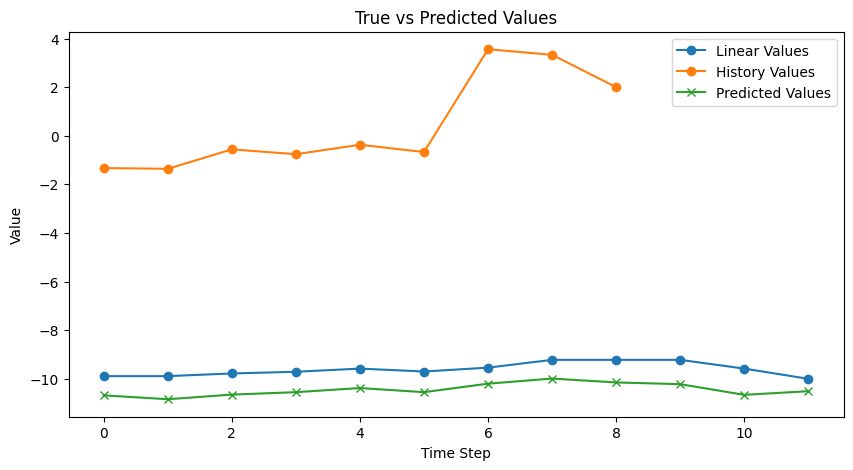

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-5.000e-02  2.000e-02  1.000e-02  2.000e-02  2.000e-02  1.000e-02  2.000e-02  6.000e-02  5.000e-02  2.000e-02 -5.000e-02 -1.002e+01]


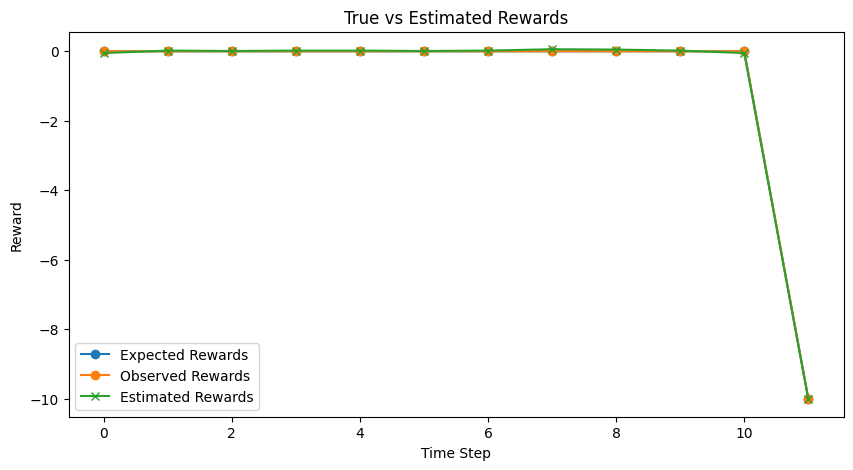

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -8.85]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.08 -0.22 -0.2   0.06  0.3  -0.1   0.01  0.03  0.02 -0.01 -8.68]


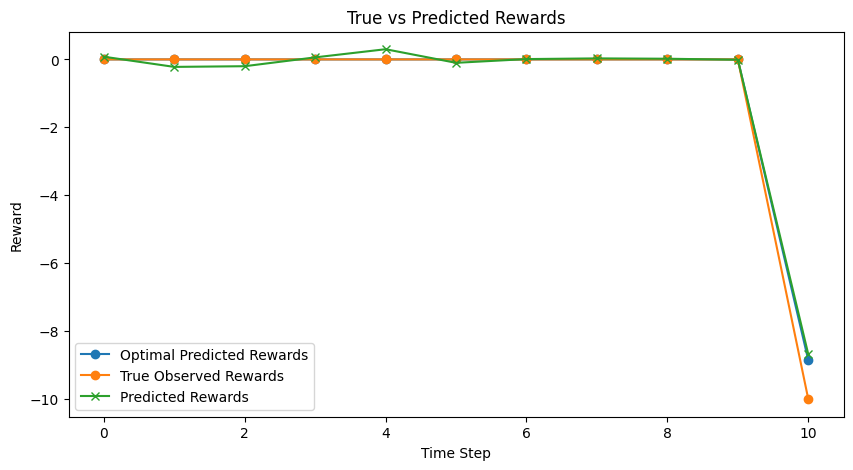

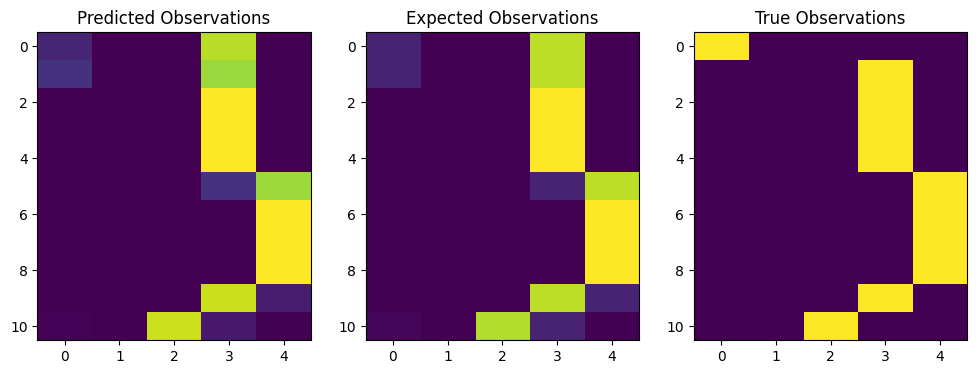

Linear Values:
[ -9.89  -9.78  -9.78  -9.65  -9.65  -9.65  -9.65  -9.78  -9.78  -9.78  -9.71  -9.77  -9.89 -10.  ]
History Values:
[-1.33, -0.49, -0.56, 2.76, 2.95, 8.18, nan, nan, nan, nan, nan, nan, nan, nan]
Predicted Values:
[-10.68 -10.55 -10.69 -10.26 -10.44 -10.3  -10.24 -10.64 -10.69 -10.7  -10.51 -10.62 -10.89 -10.24]


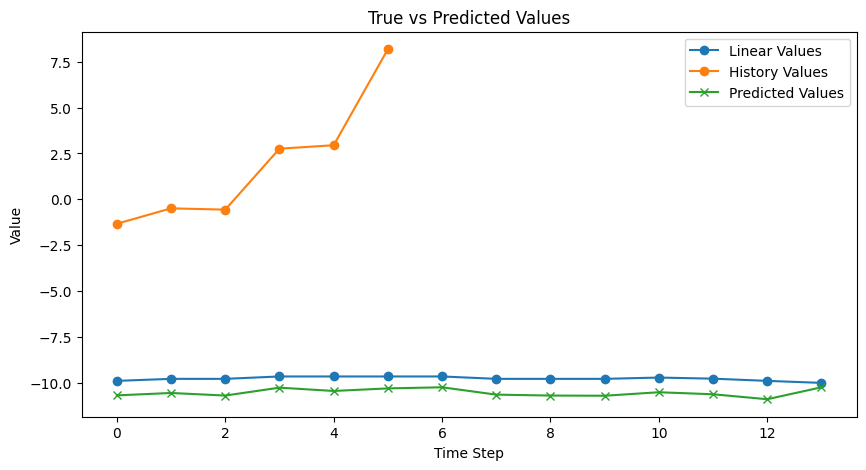

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.05 -0.02  0.02  0.06  0.01  0.01 -0.02  0.09  0.    0.04  0.05 -0.   -0.   -9.99]


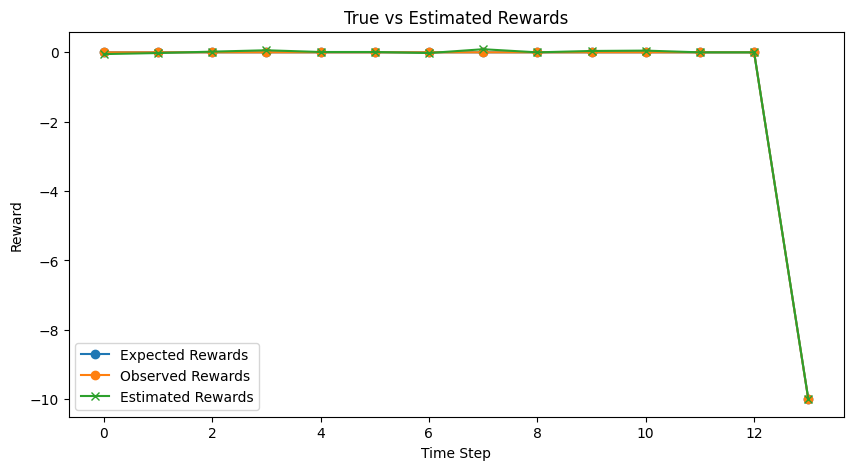

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -0.81 -9.  ]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.08  0.09  0.02  0.02  0.    0.    0.12  0.22  0.17 -0.07 -0.13 -1.43 -9.03]


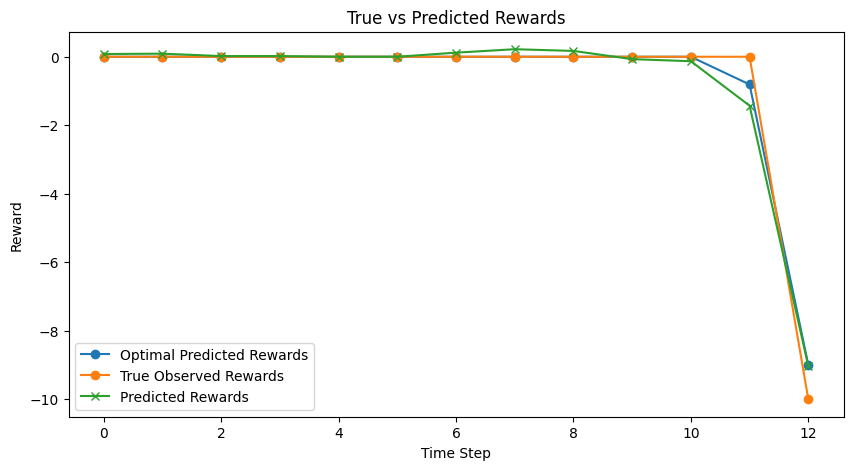

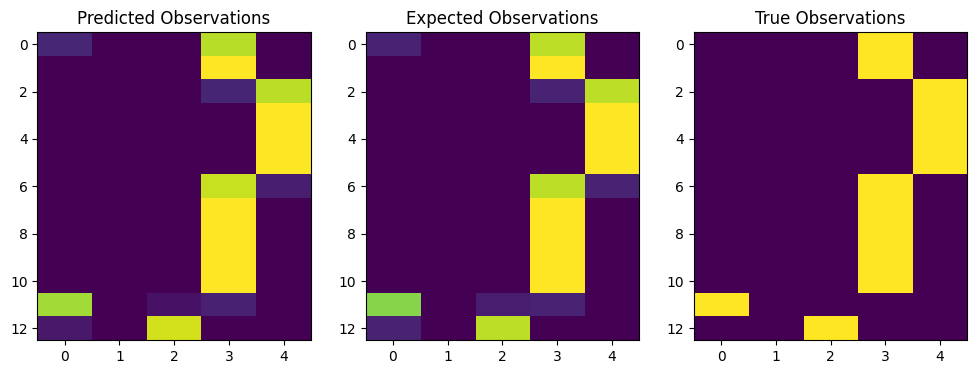

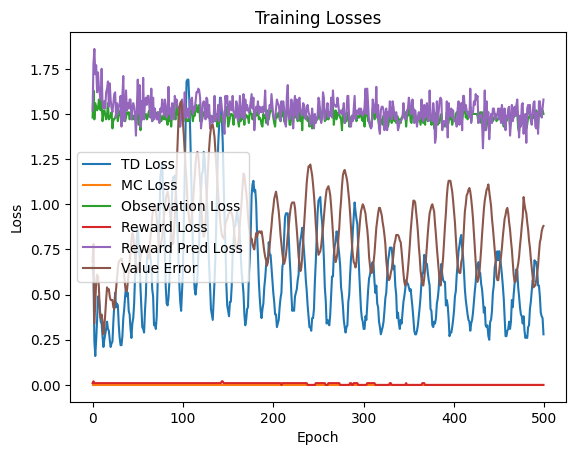

Epoch 1, TD Loss: 0.29, MC Loss: 0.0, Pred O Loss: 1.44, Est R Loss: 0.0, Pred R Loss: 1.5 Total: 3.23, Value Loss: 0.87     
Epoch 50, TD Loss: 0.26, MC Loss: 0.0, Pred O Loss: 1.46, Est R Loss: 0.0, Pred R Loss: 1.44 Total: 3.16, Value Loss: 0.48     
Epoch 100, TD Loss: 0.47, MC Loss: 0.0, Pred O Loss: 1.46, Est R Loss: 0.0, Pred R Loss: 1.51 Total: 3.44, Value Loss: 0.61     
Epoch 150, TD Loss: 0.72, MC Loss: 0.0, Pred O Loss: 1.47, Est R Loss: 0.0, Pred R Loss: 1.42 Total: 3.61, Value Loss: 0.57     
Epoch 200, TD Loss: 0.59, MC Loss: 0.0, Pred O Loss: 1.44, Est R Loss: 0.0, Pred R Loss: 1.5 Total: 3.53, Value Loss: 0.68      
Epoch 250, TD Loss: 0.57, MC Loss: 0.0, Pred O Loss: 1.46, Est R Loss: 0.0, Pred R Loss: 1.55 Total: 3.58, Value Loss: 0.73     
Epoch 300, TD Loss: 0.28, MC Loss: 0.0, Pred O Loss: 1.48, Est R Loss: 0.0, Pred R Loss: 1.5 Total: 3.26, Value Loss: 0.86      
Epoch 350, TD Loss: 0.42, MC Loss: 0.0, Pred O Loss: 1.48, Est R Loss: 0.0, Pred R Loss: 1.59 Total: 

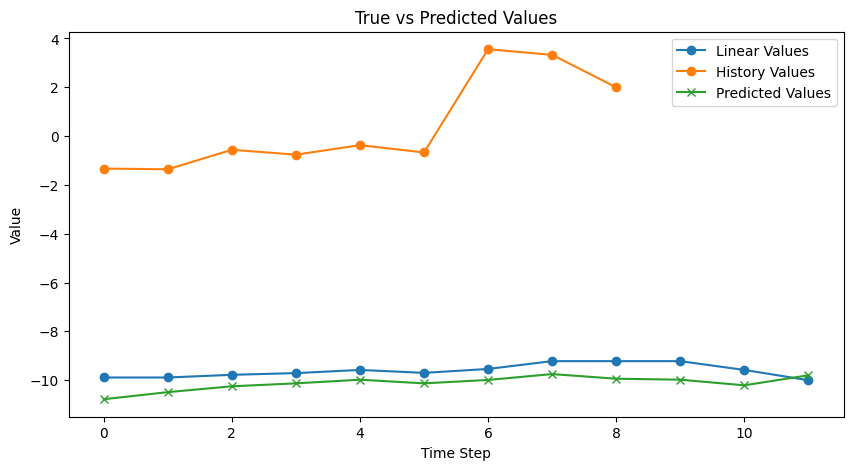

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-3.000e-02  2.000e-02 -1.000e-02  1.000e-02  3.000e-02  3.000e-02  2.000e-02  4.000e-02  6.000e-02  5.000e-02 -2.000e-02 -1.002e+01]


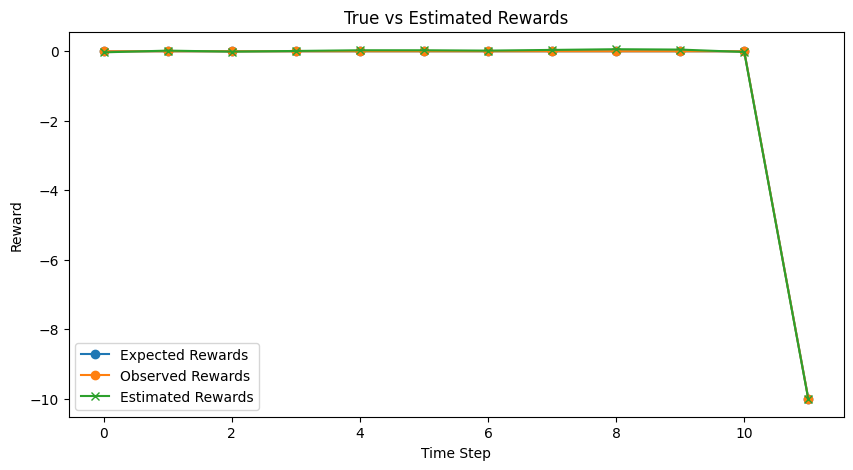

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -8.85]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.03 -0.25 -0.16  0.02  0.21 -0.12 -0.06 -0.03 -0.01 -0.04 -9.06]


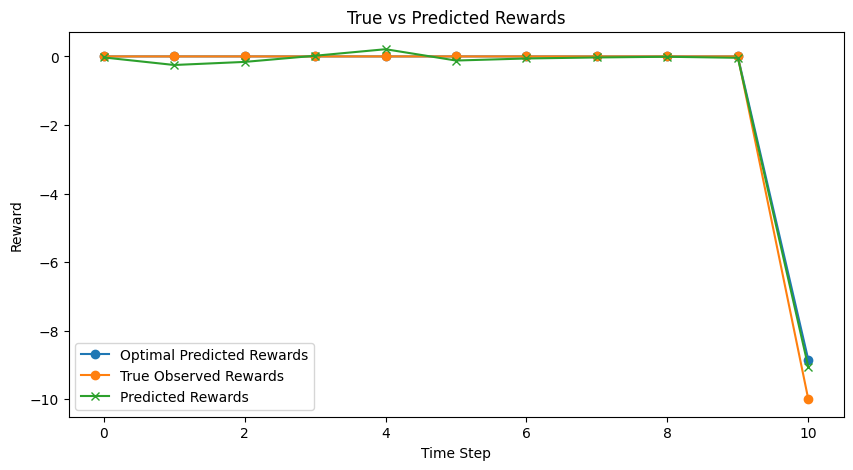

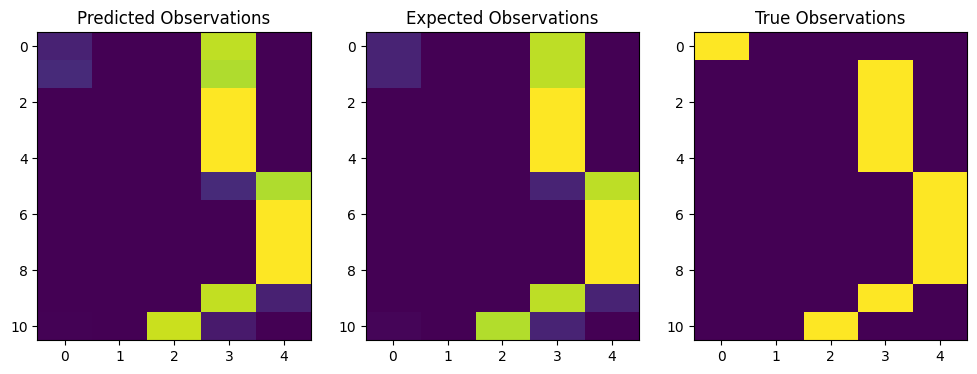

Linear Values:
[ -9.89  -9.78  -9.78  -9.65  -9.65  -9.65  -9.65  -9.78  -9.78  -9.78  -9.71  -9.77  -9.89 -10.  ]
History Values:
[-1.33, -0.49, -0.56, 2.76, 2.95, 8.18, nan, nan, nan, nan, nan, nan, nan, nan]
Predicted Values:
[-10.78 -10.2  -10.23  -9.98 -10.11 -10.06 -10.   -10.15 -10.2  -10.23 -10.07 -10.13 -10.3   -9.61]


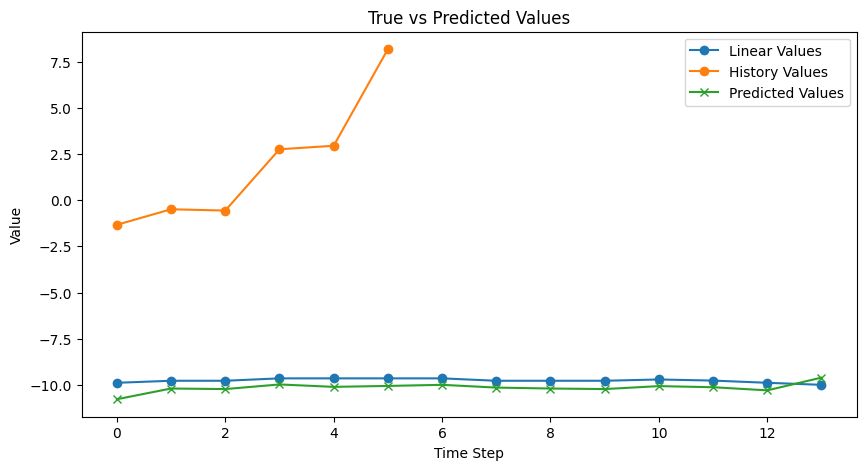

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.03 -0.02  0.02  0.05  0.   -0.01 -0.04  0.08  0.    0.04  0.05  0.    0.   -9.99]


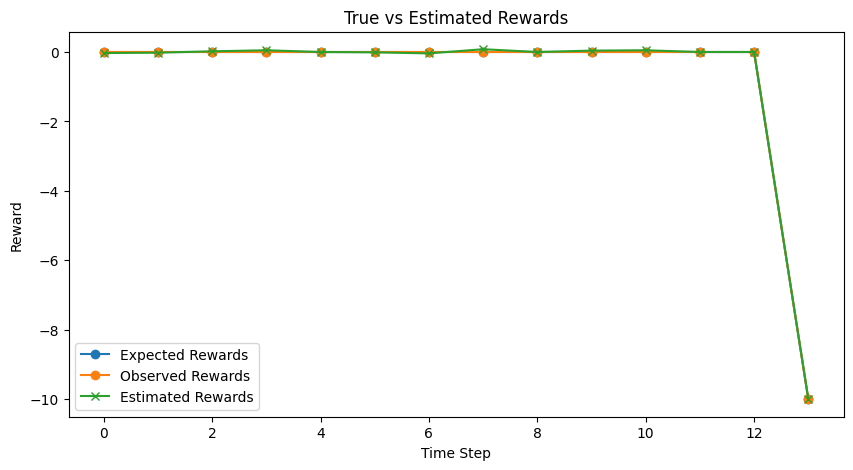

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -0.81 -9.  ]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[-0.03  0.08  0.05  0.02 -0.06 -0.08  0.01  0.19  0.2  -0.06 -0.21 -1.24 -9.11]


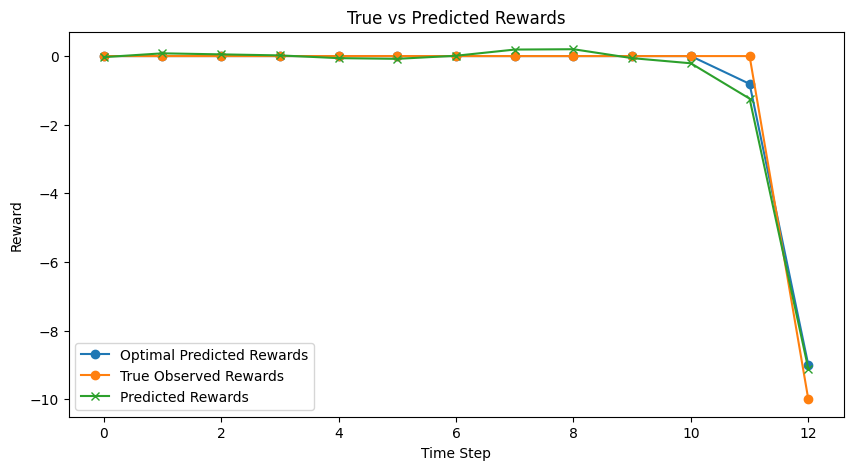

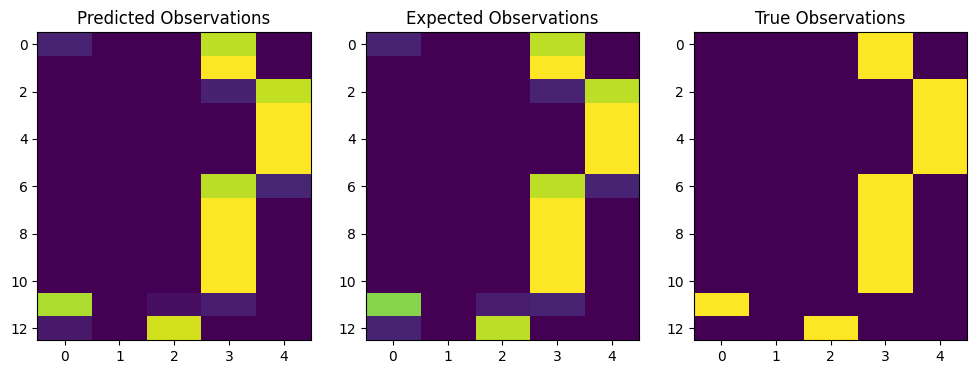

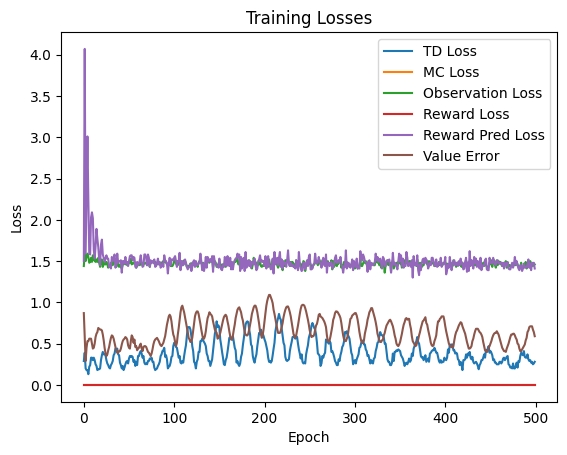

Epoch 1, TD Loss: 0.26, MC Loss: 0.0, Pred O Loss: 1.49, Est R Loss: 0.0, Pred R Loss: 1.51 Total: 3.26, Value Loss: 0.55     
Epoch 50, TD Loss: 0.2, MC Loss: 0.0, Pred O Loss: 1.44, Est R Loss: 0.0, Pred R Loss: 1.4 Total: 3.04, Value Loss: 0.38       
Epoch 100, TD Loss: 0.43, MC Loss: 0.0, Pred O Loss: 1.46, Est R Loss: 0.0, Pred R Loss: 1.47 Total: 3.36, Value Loss: 0.54     
Epoch 150, TD Loss: 0.41, MC Loss: 0.0, Pred O Loss: 1.45, Est R Loss: 0.0, Pred R Loss: 1.45 Total: 3.31, Value Loss: 0.9      
Epoch 200, TD Loss: 0.41, MC Loss: 0.0, Pred O Loss: 1.49, Est R Loss: 0.0, Pred R Loss: 1.5 Total: 3.4, Value Loss: 1.07        
Epoch 250, TD Loss: 0.82, MC Loss: 0.0, Pred O Loss: 1.45, Est R Loss: 0.0, Pred R Loss: 1.38 Total: 3.65, Value Loss: 0.83      
Epoch 300, TD Loss: 0.37, MC Loss: 0.0, Pred O Loss: 1.41, Est R Loss: 0.0, Pred R Loss: 1.4 Total: 3.18, Value Loss: 0.71      
Epoch 350, TD Loss: 0.19, MC Loss: 0.0, Pred O Loss: 1.48, Est R Loss: 0.0, Pred R Loss: 1.48 Tota

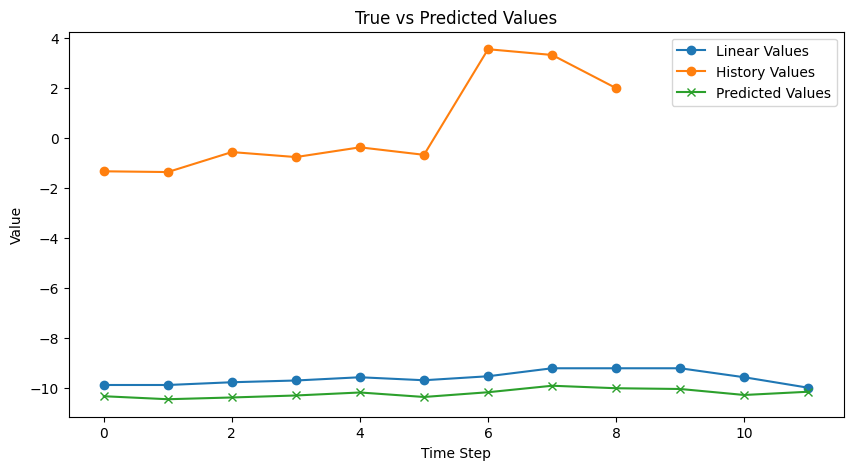

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-1.000e-02  2.000e-02 -2.000e-02 -0.000e+00  1.000e-02  0.000e+00  0.000e+00  2.000e-02  6.000e-02  6.000e-02 -4.000e-02 -1.004e+01]


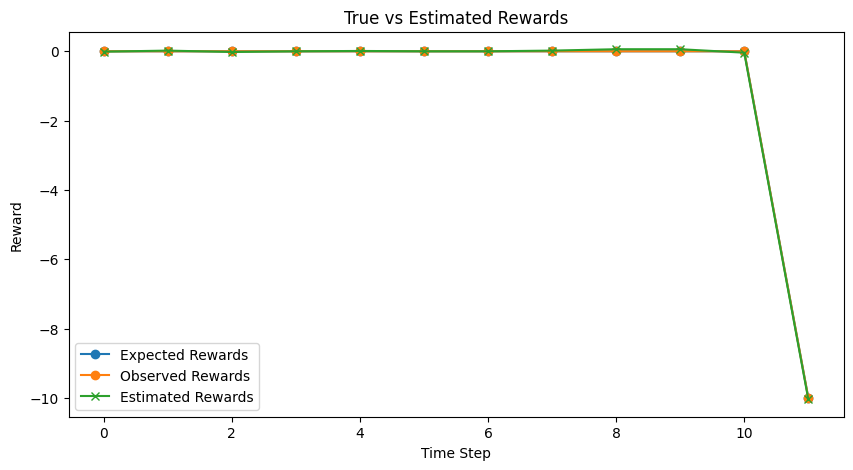

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -8.85]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.04 -0.17 -0.1   0.06  0.22 -0.08 -0.1   0.03  0.05  0.04 -9.  ]


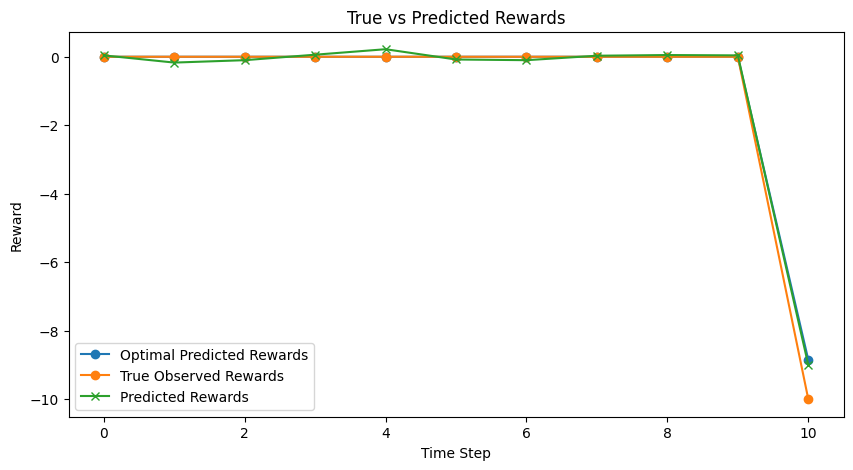

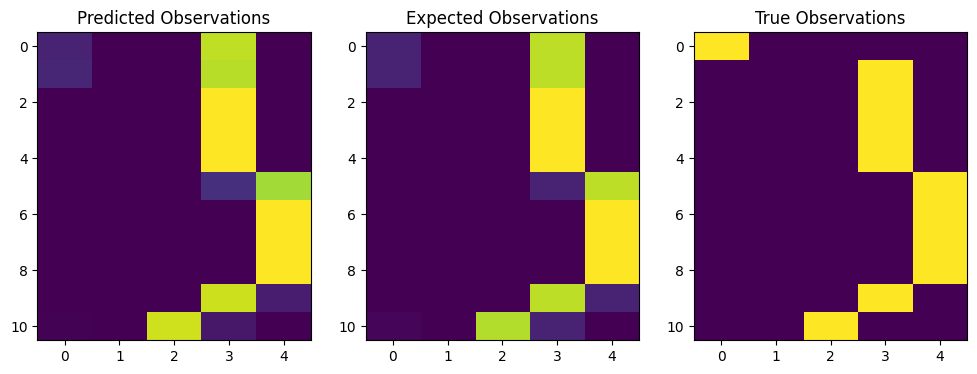

Linear Values:
[ -9.89  -9.78  -9.78  -9.65  -9.65  -9.65  -9.65  -9.78  -9.78  -9.78  -9.71  -9.77  -9.89 -10.  ]
History Values:
[-1.33, -0.49, -0.56, 2.76, 2.95, 8.18, nan, nan, nan, nan, nan, nan, nan, nan]
Predicted Values:
[-10.34 -10.26 -10.32 -10.14 -10.16 -10.18 -10.14 -10.27 -10.33 -10.35 -10.26 -10.28 -10.39  -9.99]


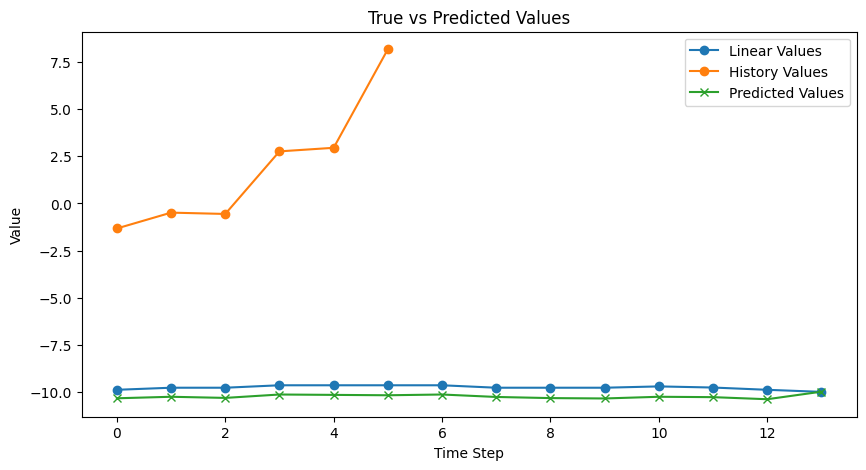

True Expected Rewards:
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Estimated Rewards:
[-0.01 -0.02  0.01  0.05  0.02 -0.02 -0.04  0.05 -0.01  0.04  0.03 -0.04 -0.01 -9.99]


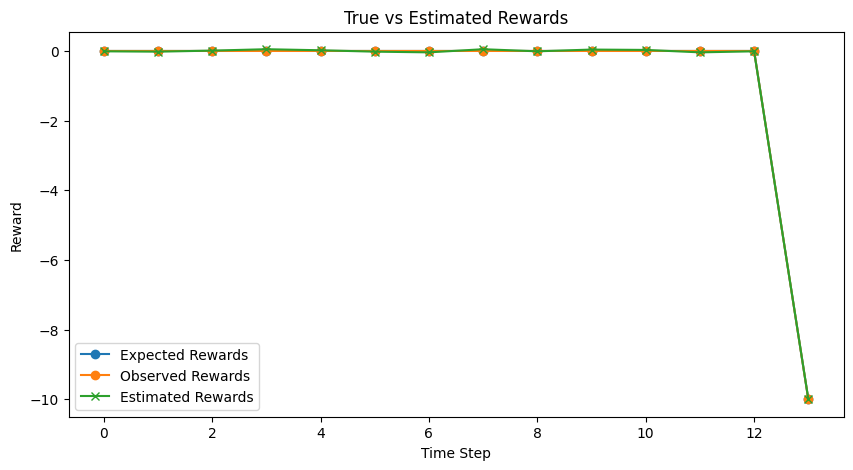

True Expected Rewards:
[ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   -0.81 -9.  ]
True Observed rewards
[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. -10.]
Predicted Rewards:
[ 0.04  0.1   0.05  0.05  0.01 -0.03  0.04  0.25  0.12 -0.04 -0.13 -0.97 -9.06]


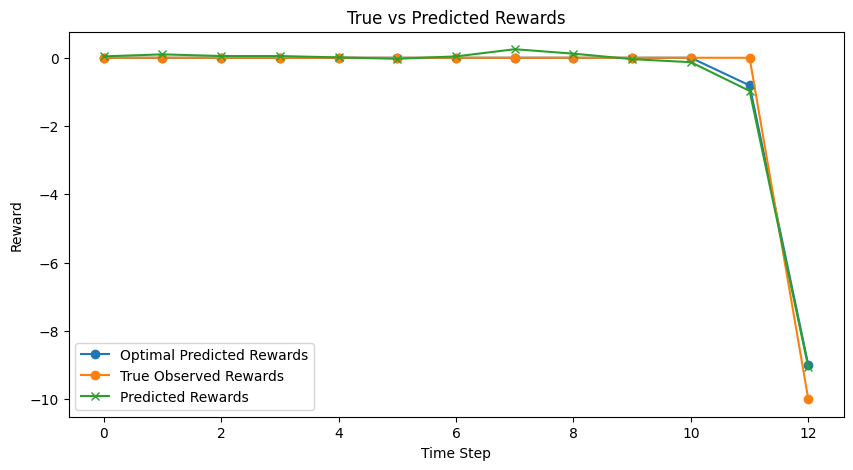

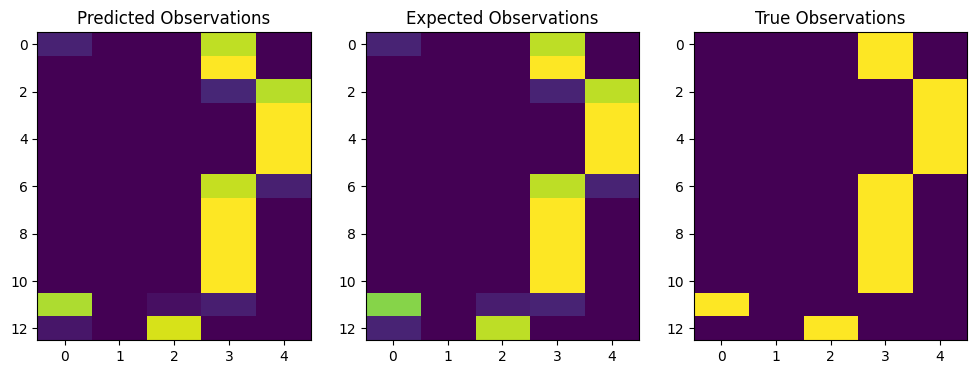

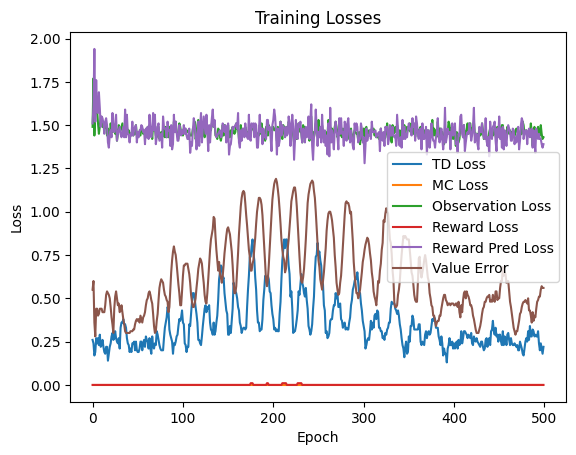

In [10]:
EPOCH = 500


for i in range(5):
    losses, models = train(
        models,
        episodes, value_empirical, 
        num_epochs=EPOCH, gamma=1.0, lr=1e-3,  batch_size=2500,
        lambda_opl=10.0, lambda_rel=1.0, lambda_rpl=1.0, lambda_mc=0.0,
        )
    plot_validate(models, test_episodes, cliff, history_vtable, value_empirical)

    # Plot the training losses
    plot_train_losses(losses)




[-10.34 -10.26 -10.32 -10.14 -10.16 -10.18 -10.14 -10.27 -10.33 -10.35 -10.26 -10.28 -10.39  -9.99]
[[ 0.5129359   0.8730152  -0.7676535  -0.89239883 -1.1358602  -1.1621408  -0.46930435  1.2943306   0.71244884 -0.70876145  1.6788757   0.48051918
  -0.9403429  -1.0200213   0.45176882  1.1013455   0.87239516  0.21108931 -0.785931    0.67353714 -0.54299915  1.8661171   0.9634776  -0.54170644
   0.83770216  0.6193836  -0.87299603 -1.0084436   0.928753   -0.5930545  -1.1079974   1.0443918   0.36071646 -0.97431433 -0.9998629  -0.26823854
   0.69641405  1.0609556   0.11523528 -0.67959857 -0.74354804 -0.8362361  -1.2487854   0.6341177   0.5568518  -0.42071488  0.99073565  0.88344646
  -0.7589383   0.27381894 -0.1167475   1.427886    0.8567943  -0.9122528   1.2980905   1.488367    0.87967193 -0.6619145  -0.8403133   0.59017396
   0.41190198  0.70113206 -0.98935795  0.36981973]
 [-0.09741994  0.3759013  -0.23358001 -0.41862452 -0.8970651  -1.0363803  -0.21193981  0.52905166  0.5349968  -0.910034

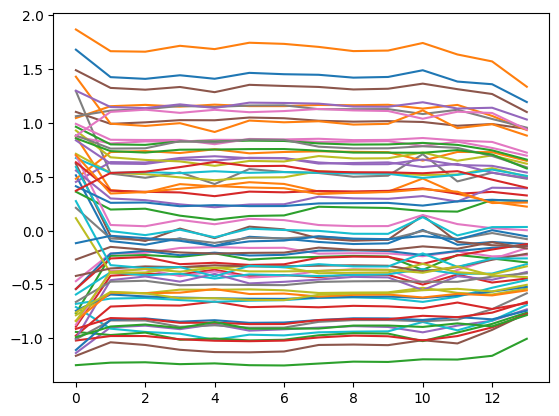

In [ ]:
w_vectors = []
device = next(belief_model.parameters()).device
with torch.no_grad():
    history = torch.tensor(test_episode.history, dtype=torch.float32).unsqueeze(0).to(device)  # shape: [1, T, D]

    z = belief_model(history)  # shape: [1, T]
    predicted_values = value_model(z)
    w_vectors.append(value_model.reveal_w(z).cpu().numpy())
    values = predicted_values.squeeze(0).cpu().numpy()  # shape: [T]

    values = np.round(values, 2)

w_vectors = np.array(w_vectors)[0,0]

plt.plot(w_vectors)

In [11]:
all_belief_states = []
for episode in episodes.episodes:
    all_belief_states.append(np.array(episode.belief_states))
all_belief_states = np.concatenate(all_belief_states, axis=0)
belief_entropy = estimate_entropy(all_belief_states, base=np.e)

print(f"Average Entropy of Belief over states: {belief_entropy}:")


# Iterate over linear and non-linear decoders
for type in ['lin', 'nonlin']:
    if type == 'lin':
        print("Linear Decoder")
        belief_decoder = LinBeliefDecoder(input_dim=episodes.H, belief_dim=episodes.S)
    else:
        print("Non-Linear Decoder")
        belief_decoder = NonLinBeliefDecoder(input_dim=episodes.H, hidden_dim=64, belief_dim=episodes.S)

    belief_decoder, loss = decode_training(
        episodes, belief_decoder, [0, None], 
        value_RNN=None, num_epochs=5000, lr=1e-3)
    
    if type == 'lin':
        CEb_true_lin = loss
    else:
        CEb_true_nonlin = loss
    
    decode_visualisation(test_episode, belief_decoder, indices=[0,None], env_size = (3, 8), value_RNN=None)



Average Entropy of Belief over states: 0.29:
Linear Decoder


KeyboardInterrupt: 

In [ ]:
EPOCHS = np.arange(0, EPOCH, 500)

CEs_true_lin = []
CEs_true_nonlin = []
    
# Iterate over epochs
for epoch in EPOCHS:
    # Load the value RNN model from the checkpoint
    model_dict = torch.load(f"checkpoints/checkpoint_epoch_{epoch}.pth", weights_only=True)
    value_RNN.load_state_dict(model_dict['model_state_dict'])
    print(f"\nUsing Value RNN from epoch {epoch}")
    
    # Iterate over linear and non-linear decoders
    for type in ['lin', 'nonlin']:
        if type == 'lin':
            print("Linear Decoder")
            belief_decoder = LinBeliefDecoder(input_dim=value_RNN.latent_dim, belief_dim=episodes.S)
        else:
            print("Non-Linear Decoder")
            belief_decoder = NonLinBeliefDecoder(input_dim=value_RNN.latent_dim, hidden_dim=16, belief_dim=episodes.S)

        belief_decoder, loss = decode_training(
            episodes, belief_decoder, [0, None], 
            value_RNN=value_RNN, num_epochs=5000, lr=1e-3)
        
        if type == 'lin':
            CEs_true_lin.append(loss)
        else:
            CEs_true_nonlin.append(loss)

        if epoch == 0 or epoch == EPOCHS[-1]:
           decode_visualisation(test_episode, belief_decoder, [0, None], env_size = (3, 8), value_RNN=value_RNN)

estimated_KL_start_lin = [CEb_true_lin - belief_entropy]
estimated_KL_start_nonlin = [CEb_true_nonlin - belief_entropy]
estimated_KL_train_lin = [CEs_true_lin - belief_entropy]
estimated_KL_train_nonlin = [CEs_true_nonlin - belief_entropy]

plt.plot(EPOCHS, CEs_true_lin - belief_entropy, label='CE True Linear', marker='o')
plt.scatter(-100, CEb_true_lin - belief_entropy, color='red', marker='x')
plt.title("Cross-Entropy Loss for True Linear Belief Decoder")
plt.show()

plt.plot(EPOCHS, CEs_true_nonlin - belief_entropy, label='CE True Non-Linear', marker='o')
plt.scatter(-100, CEb_true_nonlin - belief_entropy, color='red', marker='x')
plt.title("Cross-Entropy Loss for True Non-Linear Belief Decoder")
plt.show()